# **Klasifikasi Kualitas Beras**

## **Eksplorasi dan Visualisasi Data**

### **Import Library**

In [ ]:
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Flatten
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

### **Mount Google Drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### **Definisi Path Dataset**

In [ ]:
# Path direktori utama
BASE_DIR = '/content/drive/MyDrive/Dataset/rice'

# Definisi nama 4 label
LABELS = ['whole', 'chalky', 'broken', 'discolored']

# Dictionary untuk menyimpan path masing-masing label
label_paths = {lbl: os.path.join(BASE_DIR, lbl) for lbl in LABELS}

# Verifikasi jumlah file gambar di setiap folder label
for lbl, path in label_paths.items():
    if os.path.exists(path):
        image_count = len([f for f in os.listdir(path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
        print(f"Label '{lbl}': Ditemukan {image_count} foto.")
    else:
        print(f"Warning: Path untuk label '{lbl}' tidak ditemukan pada {path}")

Label 'whole': Ditemukan 250 foto.
Label 'chalky': Ditemukan 250 foto.
Label 'broken': Ditemukan 250 foto.
Label 'discolored': Ditemukan 250 foto.


### **Visualisasi Distribusi Dataset**

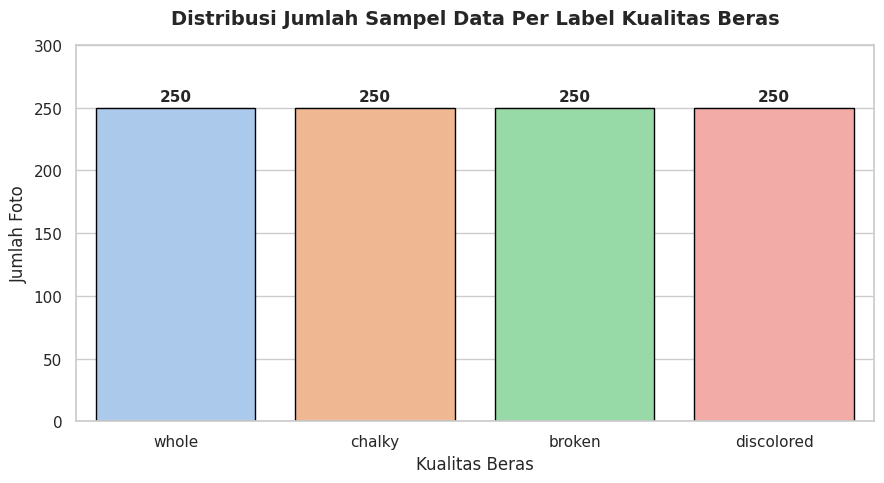

In [ ]:
# Menyiapkan data kuantitatif
label_counts = []
for lbl in LABELS:
    path = label_paths[lbl]
    if os.path.exists(path):
        count = len([f for f in os.listdir(path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
        label_counts.append(count)
    else:
        label_counts.append(0)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(9, 5))
ax = sns.barplot(x=LABELS, y=label_counts, hue=LABELS, palette="pastel", legend=False, edgecolor="black")

# Label nilai di atas setiap bar grafik
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 8),
                textcoords='offset points',
                fontsize=11,
                fontweight='bold')

plt.title('Distribusi Jumlah Sampel Data Per Label Kualitas Beras', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Kualitas Beras', fontsize=12)
plt.ylabel('Jumlah Foto', fontsize=12)
plt.ylim(0, max(label_counts) + 50)
plt.tight_layout()
plt.show()

### **Visualisasi Sampel Gambar Beras**

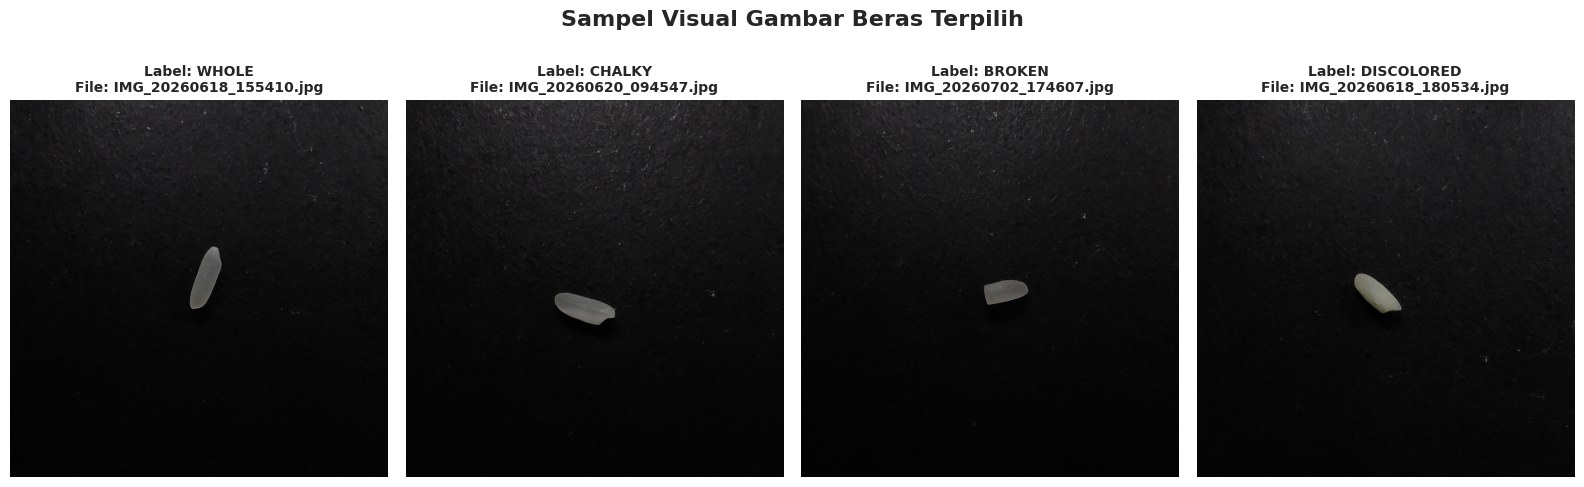

In [ ]:
# Sampel gambar secara acak
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for i, lbl in enumerate(LABELS):
    path = label_paths[lbl]
    if os.path.exists(path):
        # Ambil daftar seluruh file gambar di dalam folder label
        image_files = [f for f in os.listdir(path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        if image_files:
            # Memilih file secara acak
            random_file = random.choice(image_files)
            img_path = os.path.join(path, random_file)

            # Membaca gambar dan konversi ruang warna dari BGR ke RGB
            img = cv2.imread(img_path)
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            # Subplot
            axes[i].imshow(img_rgb)
            axes[i].set_title(f"Label: {lbl.upper()}\nFile: {random_file}", fontsize=10, fontweight='bold')
            axes[i].axis('off')
        else:
            axes[i].text(0.5, 0.5, 'Folder Kosong', ha='center', va='center')
            axes[i].axis('off')
    else:
        axes[i].text(0.5, 0.5, 'Path Tidak Ditemukan', ha='center', va='center')
        axes[i].axis('off')

plt.suptitle('Sampel Visual Gambar Beras Terpilih', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## **Perbaikan atau Penyempurnaan Gambar**

### **Filter Penyempurnaan Citra**

In [ ]:
def enhance_image(image):
    # Gaussian Blur ringan untuk mereduksi noise sensor kamera
    enhanced_img = cv2.GaussianBlur(image, (3, 3), 0)
    return enhanced_img

## **Preprocessing**

### **Segmentasi Latar Belakang dan Resizing Konsisten**

In [ ]:
def preprocess_grain_image(image, target_size=(224, 224)):
    # Konversi ruang warna ke HSV untuk akurasi segmentasi
    hsv_image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

    # Extraction channel Value (V) untuk memisahkan objek beras terang dari background
    v_channel = hsv_image[:, :, 2]

    # Binarisasi menggunakan metode Otsu Thresholding
    _, binary_mask = cv2.threshold(v_channel, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Masking bitwise untuk mengubah latar belakang asli menjadi hitam absolut
    segmented_image = cv2.bitwise_and(image, image, mask=binary_mask)

    # Standardisasi ukuran piksel
    resized_image = cv2.resize(segmented_image, target_size, interpolation=cv2.INTER_AREA)

    # Konversi hasil akhir ke RGB
    final_image = cv2.cvtColor(resized_image, cv2.COLOR_BGR2RGB)

    return final_image

### **Pipeline Ekstraksi Dataset dan Pembagian Data**

In [ ]:
# Inisialisasi list untuk menampung matriks gambar dan label numerik
features_data = []
labels_data = []

# Map nama string label ke bentuk indeks integer
label_map = {lbl: idx for idx, lbl in enumerate(LABELS)}

print("Memulai pemrosesan dataset...")

for lbl in LABELS:
    path = label_paths[lbl]
    if os.path.exists(path):
        image_files = [f for f in os.listdir(path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        current_count = 0

        for file_name in image_files:
            img_full_path = os.path.join(path, file_name)
            raw_img = cv2.imread(img_full_path)

            if raw_img is not None:
                # Sekuensial filter penyempurnaan citra
                enhanced_img = enhance_image(raw_img)

                # Segmentasi latar belakang hitam absolut & resizing
                processed_img = preprocess_grain_image(enhanced_img, target_size=(224, 224))

                # Normalisasi nilai piksel menjadi skala 0-1 untuk kestabilan konvergensi model
                normalized_img = processed_img / 255.0

                features_data.append(normalized_img)
                labels_data.append(label_map[lbl])
                current_count += 1

        print(f" -> Sukses memproses {current_count} gambar untuk label: {lbl}")

# Konversi struktur data array
X = np.array(features_data, dtype=np.float32)
y = np.array(labels_data, dtype=np.int32)

print("\nBentuk akhir matriks dataset (Shape):")
print(" - Matriks Fitur X:", X.shape)
print(" - Matriks Label y:", y.shape)

# Pembagian data secara Stratified
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("\nHasil Pembagian Data:")
print(f" -> Total Data Training   : {X_train.shape[0]} sampel")
print(f" -> Total Data Validation : {X_val.shape[0]} sampel\n")

# Verifikasi jumlah sampel per label
for i, lbl in enumerate(LABELS):
    train_count = np.sum(y_train == i)
    val_count = np.sum(y_val == i)
    print(f"Label '{lbl}': Train = {train_count} foto, Val = {val_count} foto.")

# Konversi kembali array yang sudah terbagi ke format TensorFlow
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_dataset = train_dataset.shuffle(buffer_size=len(X_train)).batch(32).prefetch(tf.data.AUTOTUNE)

val_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val))
val_dataset = val_dataset.batch(32).prefetch(tf.data.AUTOTUNE)

Memulai pemrosesan dataset...
 -> Sukses memproses 250 gambar untuk label: whole
 -> Sukses memproses 250 gambar untuk label: chalky
 -> Sukses memproses 250 gambar untuk label: broken
 -> Sukses memproses 250 gambar untuk label: discolored

Bentuk akhir matriks dataset (Shape):
 - Matriks Fitur X: (1000, 224, 224, 3)
 - Matriks Label y: (1000,)

Hasil Pembagian Data:
 -> Total Data Training   : 800 sampel
 -> Total Data Validation : 200 sampel

Label 'whole': Train = 200 foto, Val = 50 foto.
Label 'chalky': Train = 200 foto, Val = 50 foto.
Label 'broken': Train = 200 foto, Val = 50 foto.
Label 'discolored': Train = 200 foto, Val = 50 foto.


### **Visualisasi Hasil Preprocessing**

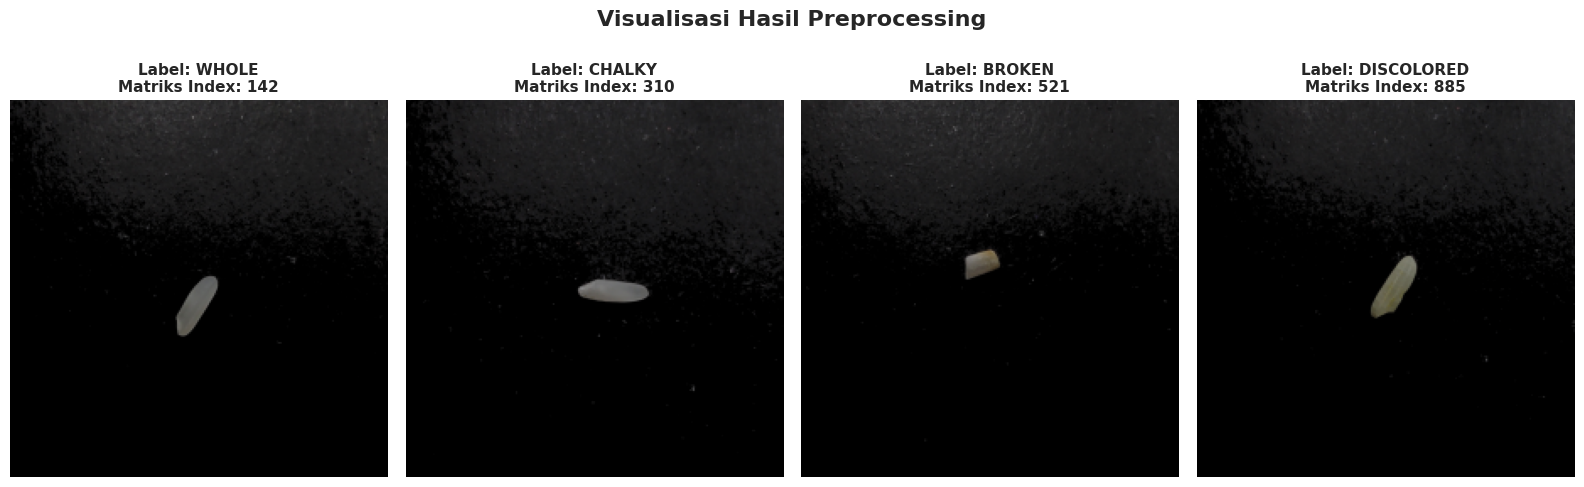

In [ ]:
# Komparasi hasil preprocessing
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for i, lbl in enumerate(LABELS):
    # Mencari seluruh indeks matriks yang memiliki label
    indices = np.where(y == i)[0]

    if len(indices) > 0:
        # Memilih satu indeks secara acak dari label
        random_idx = random.choice(indices)

        # Hasil gambar yang sudah diproses
        axes[i].imshow(X[random_idx])
        axes[i].set_title(f"Label: {lbl.upper()}\nMatriks Index: {random_idx}", fontsize=11, fontweight='bold')
        axes[i].axis('off')
    else:
        axes[i].text(0.5, 0.5, 'Data Kosong', ha='center', va='center')
        axes[i].axis('off')

plt.suptitle('Visualisasi Hasil Preprocessing', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## **Pembuatan Model**

### **Konstruksi Arsitektur Transfer Learning MobileNetV2**

In [ ]:
# Arsitektur dasar MobileNetV2 dengan pre-trained weights
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze base model layer agar bobot fitur dasar tidak berubah
base_model.trainable = False

# Custom Head Layer
x = base_model.output
x = GlobalAveragePooling2D()(x) # Mereduksi dimensi spasial fitur
x = Flatten()(x)
x = Dense(128, activation='relu')(x) # Lapisan fully connected penangkap pola kompleks
x = Dropout(0.4)(x) # Dropout layer untuk mencegah overfitting

# Output layer dengan 4 nodes menggunakan aktivasi Softmax
outputs = Dense(4, activation='softmax')(x)

# Menggabungkan komponen menjadi satu model utuh
model = Model(inputs=base_model.input, outputs=outputs)

# Ringkasan struktural arsitektur model
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

### **Kompilasi Model Deep Learning**

In [ ]:
# Mengompilasi model menggunakan Adam Optimizer
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

### **Training Model**

In [ ]:
EPOCHS = 50

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    verbose=1
)

Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 37s 744ms/step - accuracy: 0.4863 - loss: 1.2210 - val_accuracy: 0.7400 - val_loss: 0.8953
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.6538 - loss: 0.8767 - val_accuracy: 0.7650 - val_loss: 0.7159
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.7337 - loss: 0.7225 - val_accuracy: 0.7550 - val_loss: 0.6291
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.7675 - loss: 0.6223 - val_accuracy: 0.8000 - val_loss: 0.5516
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.8037 - loss: 0.5339 - val_accuracy: 0.8300 - val_loss: 0.4970
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.8200 - loss: 0.5021 - val_accuracy: 0.8400 - val_loss: 0.4591
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.8450 - loss: 0.4456 - val_accuracy: 0.8700 - val_loss: 0.4281
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.8525 - loss: 0.4294 - val_accuracy: 0.8550 -

## **Evaluasi**

### **Visualisasi Kurva Akurasi dan Loss**

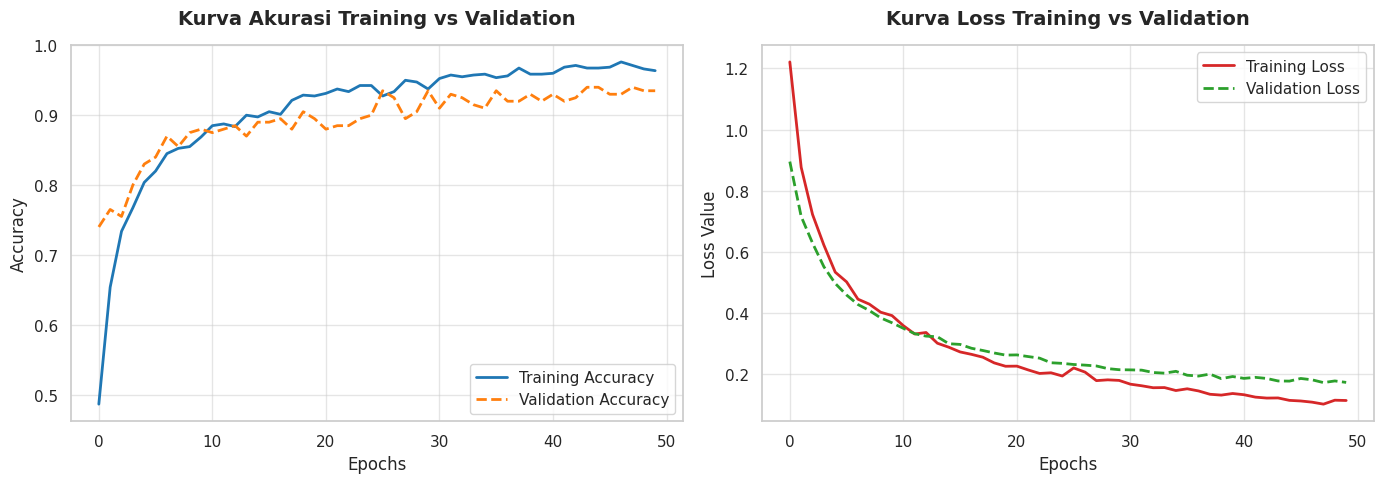

In [ ]:
# Nilai historis metrik evaluasi dari objek history training
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(EPOCHS)

plt.figure(figsize=(14, 5))

# Visualisasi perbandingan akurasi model
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', color='#1f77b4', linewidth=2)
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='#ff7f0e', linestyle='--', linewidth=2)
plt.title('Kurva Akurasi Training vs Validation', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.5)

# Visualisasi perbandingan loss model
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', color='#d62728', linewidth=2)
plt.plot(epochs_range, val_loss, label='Validation Loss', color='#2ca02c', linestyle='--', linewidth=2)
plt.title('Kurva Loss Training vs Validation', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss Value', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.5)

plt.tight_layout()
plt.show()

### **Generasi Matriks Evaluasi Klasifikasi Kuantitatif**

In [ ]:
# Mengekstrak seluruh gambar asli dan label aktual dari validation dataset
val_images = []
val_labels_actual = []

for images_batch, labels_batch in val_dataset:
    val_images.append(images_batch.numpy())
    val_labels_actual.append(labels_batch.numpy())

# Mengonversi batch menjadi satu array tunggal
X_val = np.concatenate(val_images, axis=0)
y_true = np.concatenate(val_labels_actual, axis=0)

# Memprediksi probabilitas nilai
y_pred_probabilities = model.predict(X_val)
y_pred = np.argmax(y_pred_probabilities, axis=1)

# Classification Report
print("\n====== Classification Report Kualitas Beras ======\n")
print(classification_report(y_true, y_pred, target_names=LABELS))

7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 769ms/step

====== Classification Report Kualitas Beras ======

              precision    recall  f1-score   support

       whole       0.90      0.94      0.92        50
      chalky       0.88      0.88      0.88        50
      broken       1.00      0.96      0.98        50
  discolored       0.96      0.96      0.96        50

    accuracy                           0.94       200
   macro avg       0.94      0.93      0.94       200
weighted avg       0.94      0.94      0.94       200



### **Visualisasi Heatmap Confusion Matrix**

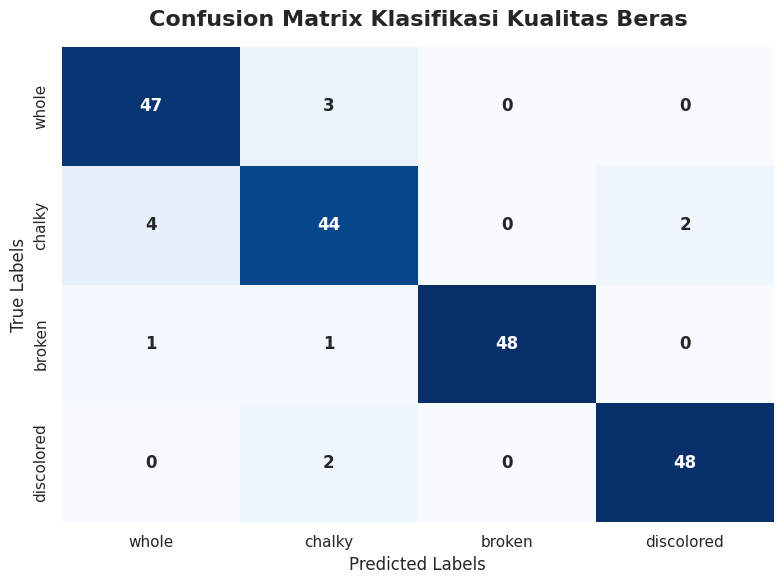

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=LABELS, yticklabels=LABELS, cbar=False,
            annot_kws={"size": 12, "weight": "bold"})

plt.title('Confusion Matrix Klasifikasi Kualitas Beras', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Predicted Labels', fontsize=12)
plt.ylabel('True Labels', fontsize=12)
plt.tight_layout()
plt.show()

### Penyimpanan Model

In [ ]:
model.save('/content/rice_quality.keras')